In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [67]:
np.random.seed(42)
torch.manual_seed(42)
 
print("All imports done!")

All imports done!


In [68]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
METRICS_DIR = RESULTS_DIR / "metrics"

# Create folders if missing
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures dir:", FIGURES_DIR)
print("Processed dir:", PROCESSED_DIR)

Project root: c:\Users\anums\Desktop\tabddpm-forward-process
Figures dir: c:\Users\anums\Desktop\tabddpm-forward-process\results\figures
Processed dir: c:\Users\anums\Desktop\tabddpm-forward-process\data\processed


In [69]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()

print(f"Training data shape: {X_train.shape}")
print(f"That means {X_train.shape[0]} patients, each with {X_train.shape[1]} features")
print(f"\nFirst 3 rows of patient data:")
print(X_train.head(3))

Training data shape: (79472, 42)
That means 79472 patients, each with 42 features

First 3 rows of patient data:
   race  gender       age  admission_type_id  discharge_disposition_id  \
0     2       1 -0.673505                  1                         1   
1     2       1 -0.046692                  3                         6   
2     2       1  0.580121                  1                         1   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                    7         -0.128423            1.123475       -0.783824   
1                    1          1.217886            1.480245        2.744038   
2                    7         -0.465000            0.613803        0.392130   

   num_medications  ...  troglitazone  tolazamide  insulin  \
0        -0.985541  ...             0           0        0   
1         5.425863  ...             0           0        3   
2         0.124125  ...             0           0        2   

   glyburide-metform

In [70]:
# To identify which columns are numeric and which are categorical
# This is important because I will add noise DIFFERENTLY to these two types
# Numeric (continuous) columns: things like age, length of stay, number of meds
# These get Gaussian noise (adding random decimal numbers)
# Categorical columns: things like race, diagnosis, gender, medication status
# These get multinomial diffusion (randomly flipping categories)
 
# These 9 columns are the continuous numeric ones
NUMERIC_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age'
]
 
# Everything else is categorical (encoded as integers)
ALL_COLS = X_train.columns.tolist()
CAT_COLS = [col for col in ALL_COLS if col not in NUMERIC_COLS]
 
print(f"Numeric (continuous) columns: {len(NUMERIC_COLS)}")
print(f"Categorical columns: {len(CAT_COLS)}")
print(f"Total: {len(NUMERIC_COLS) + len(CAT_COLS)} (should equal {X_train.shape[1]})")
 
print(f"\nNumeric columns: {NUMERIC_COLS}")
print(f"\nCategorical columns: {CAT_COLS}")
 
# For each categorical column, find how many unique categories it has.
# Needed later for multinomial diffusion.
# use max value + 1 (not nunique) because some columns have gaps
# e.g., admission_type_id might have values [1,2,3,5,8] -- max is 8, so K must be 9
NUM_CLASSES_PER_CAT = {}
for col in CAT_COLS:
    NUM_CLASSES_PER_CAT[col] = int(X_train[col].max()) + 1
 
print(f"\nNumber of unique categories per categorical column:")
for col, n in NUM_CLASSES_PER_CAT.items():
    print(f"  {col}: {n} categories")
 

Numeric (continuous) columns: 9
Categorical columns: 33
Total: 42 (should equal 42)

Numeric columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age']

Categorical columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Number of unique categories per categorical column:
  race: 5 categories
  gender: 2 categories
  admission_type_id: 9 categories
  discharge_disposition_id: 29 categories


In [71]:
# The Beta Schedule
 
# Key idea:

# Goal is to destroy a patient row in T=1000 steps
# At each step t, I will add a little bit of noise
# But how MUCH noise at each step? That's what beta controls.
#
# beta_t is a small number (between 0.0001 and 0.02) that says:
#   "at step t, mix in this much noise"
#
# I will use a LINEAR schedule, meaning beta starts tiny and grows
# in equal increments. Early steps add barely any noise (patient
# still looks real). Late steps add lots of noise (patient looks
# like random garbage).
#
# These specific values (0.0001 to 0.02) come from the original
# DDPM paper by Ho et al. 2020. They figured out through experiments
# that this range works well.
 
T = 1000  # total number of diffusion steps
 
# beta goes from 0.0001 (step 0) to 0.02 (step 999), linearly
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)
 
print(f"Total timesteps T = {T}")
print(f"Beta at step 0 (barely any noise):     {betas[0]:.6f}")
print(f"Beta at step 100:                      {betas[100]:.6f}")
print(f"Beta at step 500 (medium noise):       {betas[500]:.6f}")
print(f"Beta at step 999 (lots of noise):      {betas[999]:.6f}")
print(f"\nBeta shape: {betas.shape}")


Total timesteps T = 1000
Beta at step 0 (barely any noise):     0.000100
Beta at step 100:                      0.002092
Beta at step 500 (medium noise):       0.010060
Beta at step 999 (lots of noise):      0.020000

Beta shape: torch.Size([1000])


In [72]:
# Compute alpha and alpha_bar from beta 
 
# Now I need to derive two more quantities from beta. These are just math
# shortcuts that make the forward process formula simpler.
#
# alpha_t = 1 - beta_t
#   (if beta is the "noise fraction", alpha is the "keep fraction")
#
# alpha_bar_t = alpha_0 * alpha_1 * alpha_2 * ... * alpha_t
#   This is the cumulative product. It tells you: after ALL steps
#   from 0 to t, how much of the original patient is left?
#
# Why do we need alpha_bar? Because of a math trick:
# Instead of running noise 500 times one step at a time, we can
# jump DIRECTLY to step 500 in one shot using alpha_bar.
# The formula is:
#
#   x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
#
# where x_0 is the original patient and noise is random numbers.

 
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
 
print("Alpha at step 0 (keeps almost everything):", f"{alphas[0]:.6f}")
print("Alpha at step 999 (keeps very little):    ", f"{alphas[999]:.6f}")
print()
print("Alpha_bar at step 0 (original is ~100% preserved):  ", f"{alpha_bars[0]:.6f}")
print("Alpha_bar at step 250 (original is partly gone):    ", f"{alpha_bars[250]:.6f}")
print("Alpha_bar at step 500 (original is mostly gone):    ", f"{alpha_bars[500]:.6f}")
print("Alpha_bar at step 999 (original is ~0% -- pure noise):", f"{alpha_bars[999]:.6f}")

Alpha at step 0 (keeps almost everything): 0.999900
Alpha at step 999 (keeps very little):     0.980000

Alpha_bar at step 0 (original is ~100% preserved):   0.999900
Alpha_bar at step 250 (original is partly gone):     0.521423
Alpha_bar at step 500 (original is mostly gone):     0.077797
Alpha_bar at step 999 (original is ~0% -- pure noise): 0.000040


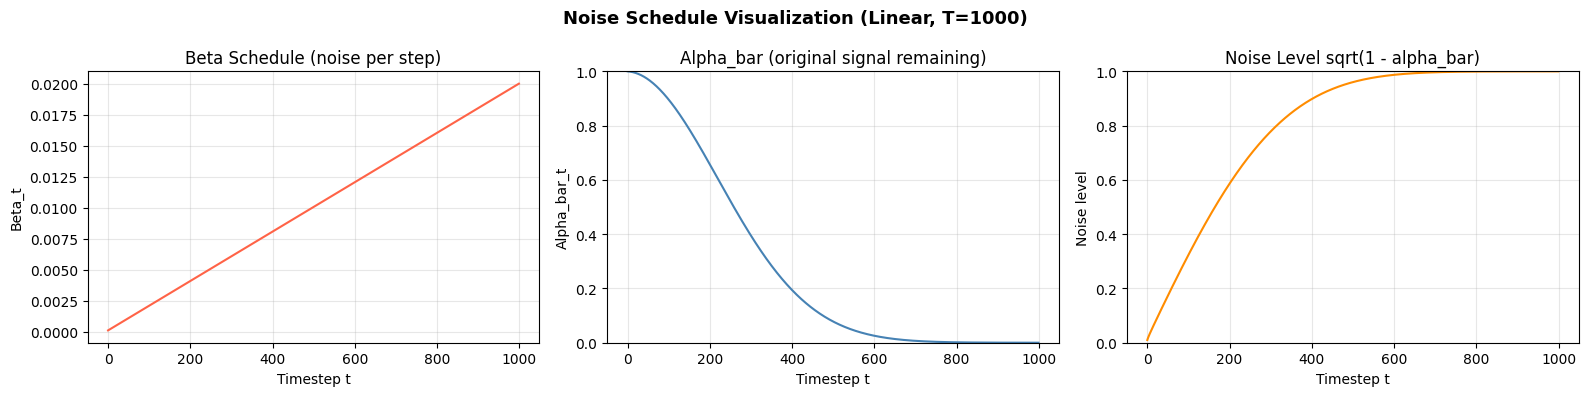

Plot saved to results/figures/noise_schedule.png

READ THE PLOTS:
- Left: beta grows linearly. Early steps = tiny noise. Late steps = big noise.
- Middle: alpha_bar drops from ~1 to ~0. This means the original patient data
  starts fully preserved and ends up completely destroyed.
- Right: the noise level (how much random noise is in the mix) goes from ~0 to ~1.


In [73]:
# Visualize the schedule 
 
# This plot is IMPORTANT for report. It shows how the noise
# schedule works over the 1000 steps.
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# Plot 1: Beta schedule (noise added per step)
axes[0].plot(range(T), betas.numpy(), color='tomato', linewidth=1.5)
axes[0].set_title("Beta Schedule (noise per step)")
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel("Beta_t")
axes[0].grid(alpha=0.3)
 
# Plot 2: Alpha bar (how much original signal remains)
axes[1].plot(range(T), alpha_bars.numpy(), color='steelblue', linewidth=1.5)
axes[1].set_title("Alpha_bar (original signal remaining)")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel("Alpha_bar_t")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
 
# Plot 3: sqrt(1 - alpha_bar) = the noise level at each step
noise_level = torch.sqrt(1.0 - alpha_bars)
axes[2].plot(range(T), noise_level.numpy(), color='darkorange', linewidth=1.5)
axes[2].set_title("Noise Level sqrt(1 - alpha_bar)")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("Noise level")
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)
 
plt.suptitle("Noise Schedule Visualization (Linear, T=1000)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/"noise_schedule.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("Plot saved to results/figures/noise_schedule.png")
print("\nREAD THE PLOTS:")
print("- Left: beta grows linearly. Early steps = tiny noise. Late steps = big noise.")
print("- Middle: alpha_bar drops from ~1 to ~0. This means the original patient data")
print("  starts fully preserved and ends up completely destroyed.")
print("- Right: the noise level (how much random noise is in the mix) goes from ~0 to ~1.")
 

In [74]:
# Quick sanity check for verifications
 
 
print("SANITY CHECKS\n")
 
# Check 1: betas should all be between 0 and 1
assert (betas >= 0).all() and (betas <= 1).all(), "FAIL: betas out of range!"
print("[PASS] All betas are between 0 and 1")
 
# Check 2: alpha_bars should decrease monotonically (always going down)
diffs = alpha_bars[1:] - alpha_bars[:-1]
assert (diffs <= 0).all(), "FAIL: alpha_bar is not always decreasing!"
print("[PASS] Alpha_bar is always decreasing (noise always increasing)")
 
# Check 3: alpha_bar at step 0 should be close to 1 (barely any noise)
assert alpha_bars[0] > 0.99, "FAIL: alpha_bar[0] should be ~1.0!"
print(f"[PASS] Alpha_bar[0] = {alpha_bars[0]:.6f} (close to 1, good)")
 
# Check 4: alpha_bar at step 999 should be close to 0 (pure noise)
assert alpha_bars[999] < 0.01, "FAIL: alpha_bar[999] should be ~0.0!"
print(f"[PASS] Alpha_bar[999] = {alpha_bars[999]:.6f} (close to 0, good)")
 
# Check 5: shapes should all be (1000,)
assert betas.shape == (T,), "FAIL: betas wrong shape!"
assert alphas.shape == (T,), "FAIL: alphas wrong shape!"
assert alpha_bars.shape == (T,), "FAIL: alpha_bars wrong shape!"
print(f"[PASS] All shapes are ({T},)")
 
print("\nALL CHECKS PASSED. Noise schedule is correct!")

SANITY CHECKS

[PASS] All betas are between 0 and 1
[PASS] Alpha_bar is always decreasing (noise always increasing)
[PASS] Alpha_bar[0] = 0.999900 (close to 1, good)
[PASS] Alpha_bar[999] = 0.000040 (close to 0, good)
[PASS] All shapes are (1000,)

ALL CHECKS PASSED. Noise schedule is correct!


In [75]:
# The Gaussian forward process function 
 
# This function takes a real patient's numeric values and a timestep t,
# and returns a noisy version of those values.
#
# It uses the formula:
#   x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
#
# where epsilon is random noise sampled from N(0, 1).
#
# IMPORTANT: this function also RETURNS the noise it used, because
# later during training, the neural network's job is to PREDICT this
# exact noise. So Rohith's training loop will need both the noisy
# data AND the noise that was added.
 
def q_sample_gaussian(x_0, t, alpha_bars):
    """
    Add noise to continuous/numeric data at timestep t.
 
    Args:
        x_0: original patient data, shape (batch_size, num_features)
             this is a torch tensor of the numeric columns only
        t: timestep(s), shape (batch_size,)
           each patient in the batch can be at a different timestep
        alpha_bars: the precomputed alpha_bar values, shape (T,)
 
    Returns:
        x_t: the noisy version of x_0 at timestep t
        noise: the exact noise that was added (needed for training)
    """
    # grab alpha_bar values for each patient's timestep
    # reshape to (batch_size, 1) so it broadcasts across features
    a_bar = alpha_bars[t].unsqueeze(1)  # shape: (batch_size, 1)
 
    # sample random noise, same shape as input data
    noise = torch.randn_like(x_0)  # random numbers from N(0,1)
 
    # apply the forward process formula
    # sqrt(alpha_bar) * original + sqrt(1 - alpha_bar) * noise
    x_t = torch.sqrt(a_bar) * x_0 + torch.sqrt(1.0 - a_bar) * noise
 
    return x_t, noise
 
 
print("q_sample_gaussian function defined!")
print("This takes real patient numeric values + a timestep, returns noisy version + the noise used.")
 

q_sample_gaussian function defined!
This takes real patient numeric values + a timestep, returns noisy version + the noise used.


In [76]:
# Test it on a single patient
 
# Let's grab one real patient and see what happens when
# I noise them at different timesteps.
 
# pick patient row 0, just the numeric columns
patient_0_numeric = torch.tensor(
    X_train[NUMERIC_COLS].iloc[0].values, dtype=torch.float32
)
 
print("Original patient (numeric columns only):")
print("-" * 60)
for col, val in zip(NUMERIC_COLS, patient_0_numeric.numpy()):
    print(f"  {col:30s} = {val:+.4f}")
 
# now noise this patient at steps 0, 100, 500, 999
# need to reshape to (1, 9) because function expects batches
patient_batch = patient_0_numeric.unsqueeze(0)  # shape: (1, 9)
 
print("\n" + "=" * 60)
print("Same patient at different noise levels:")
print("=" * 60)
 
for step in [0, 100, 250, 500, 750, 999]:
    t_tensor = torch.tensor([step])
    noisy_patient, noise_used = q_sample_gaussian(patient_batch, t_tensor, alpha_bars)
 
    # how much original vs noise at this step
    signal_pct = float(alpha_bars[step]) * 100
    noise_pct = (1 - float(alpha_bars[step])) * 100
 
    print(f"\nStep {step:4d} | Original signal: {signal_pct:5.1f}% | Noise: {noise_pct:5.1f}%")
    print(f"  Values: {noisy_patient.squeeze().numpy().round(3)}")

Original patient (numeric columns only):
------------------------------------------------------------
  time_in_hospital               = -0.1284
  num_lab_procedures             = +1.1235
  num_procedures                 = -0.7838
  num_medications                = -0.9855
  number_outpatient              = -0.2938
  number_emergency               = -0.2072
  number_inpatient               = -0.5006
  number_diagnoses               = -1.2380
  age                            = -0.6735

Same patient at different noise levels:

Step    0 | Original signal: 100.0% | Noise:   0.0%
  Values: [-0.125  1.125 -0.781 -0.983 -0.305 -0.209 -0.479 -1.244 -0.669]

Step  100 | Original signal:  89.5% | Noise:  10.5%
  Values: [-0.035  1.236 -0.48  -0.573 -0.825 -0.516 -0.163 -0.743 -0.373]

Step  250 | Original signal:  52.1% | Noise:  47.9%
  Values: [-0.623  0.292  0.37  -0.237 -0.439  0.4   -0.167 -0.855 -0.125]

Step  500 | Original signal:   7.8% | Noise:  92.2%
  Values: [-0.265  0.265  0.287 -

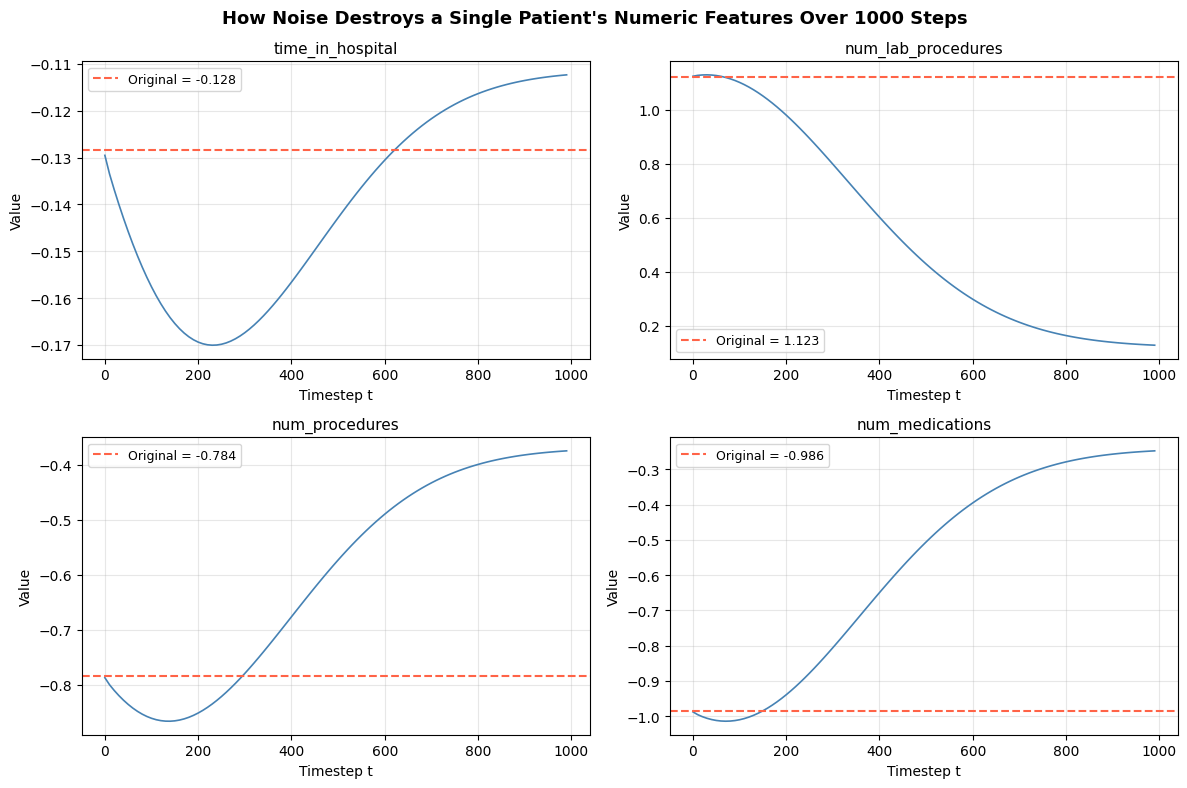

Plot saved to results/figures/noise_buildup_single_patient.png

What to see: each feature starts at the red dashed line (original value)
and drifts away as noise increases, ending up as random numbers.


In [77]:
# Visualize noise building up on one patient
 
# This is a KEY visualization for report.
# It shows how one patient's features get progressively destroyed.
 
# pick first 4 numeric features for a clean plot
features_to_plot = NUMERIC_COLS[:4]
feature_indices = [NUMERIC_COLS.index(f) for f in features_to_plot]
 
# collect the value of each feature at many timesteps
timesteps_to_show = list(range(0, 1000, 10))  # every 10 steps
values_over_time = {f: [] for f in features_to_plot}
 
# use SAME noise seed so the trajectory is smooth
torch.manual_seed(123)
 
for step in timesteps_to_show:
    t_tensor = torch.tensor([step])
    torch.manual_seed(123)  # same noise each time so values evolve smoothly
    noisy, _ = q_sample_gaussian(patient_batch, t_tensor, alpha_bars)
    for f, idx in zip(features_to_plot, feature_indices):
        values_over_time[f].append(float(noisy[0, idx]))
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for i, feat in enumerate(features_to_plot):
    axes[i].plot(timesteps_to_show, values_over_time[feat], color='steelblue', linewidth=1.2)
    # mark the original value
    orig_val = float(patient_0_numeric[feature_indices[i]])
    axes[i].axhline(y=orig_val, color='tomato', linestyle='--', linewidth=1.5,
                    label=f'Original = {orig_val:.3f}')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("Timestep t")
    axes[i].set_ylabel("Value")
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
 
plt.suptitle("How Noise Destroys a Single Patient's Numeric Features Over 1000 Steps",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/"noise_buildup_single_patient.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("Plot saved to results/figures/noise_buildup_single_patient.png")
print("\nWhat to see: each feature starts at the red dashed line (original value)")
print("and drifts away as noise increases, ending up as random numbers.")

In [78]:
# Test on a batch of patients 
 
# In real training, Rohith will not noise one patient at a time.
# He will noise a whole batch (e.g., 64 patients) at once, each
# at a DIFFERENT random timestep. Need to make sure function
# handles that correctly.
 
batch_size = 8
 
# grab 8 patients' numeric columns
batch_data = torch.tensor(
    X_train[NUMERIC_COLS].iloc[:batch_size].values, dtype=torch.float32
)
 
# give each patient a DIFFERENT random timestep
random_timesteps = torch.randint(0, T, (batch_size,))
 
# run forward process
noisy_batch, noise_batch = q_sample_gaussian(batch_data, random_timesteps, alpha_bars)
 
print(f"Input batch shape:  {batch_data.shape}  (8 patients, 9 numeric features)")
print(f"Timesteps:          {random_timesteps.tolist()}")
print(f"Output noisy shape: {noisy_batch.shape}  (same shape, good!)")
print(f"Output noise shape: {noise_batch.shape}  (same shape, good!)")
 
# verify: patient with low timestep should look similar to original
# patient with high timestep should look very different
print("\n--- Checking: does more noise = more different from original? ---")
for i in range(batch_size):
    t_val = int(random_timesteps[i])
    diff = float(torch.mean((noisy_batch[i] - batch_data[i]) ** 2))
    print(f"  Patient {i}, step {t_val:4d}: mean squared difference from original = {diff:.4f}")
 
print("\nPatients at higher timesteps should have bigger differences. Check above!")


Input batch shape:  torch.Size([8, 9])  (8 patients, 9 numeric features)
Timesteps:          [350, 16, 655, 497, 459, 102, 621, 756]
Output noisy shape: torch.Size([8, 9])  (same shape, good!)
Output noise shape: torch.Size([8, 9])  (same shape, good!)

--- Checking: does more noise = more different from original? ---
  Patient 0, step  350: mean squared difference from original = 1.8404
  Patient 1, step   16: mean squared difference from original = 0.0037
  Patient 2, step  655: mean squared difference from original = 1.1548
  Patient 3, step  497: mean squared difference from original = 0.7694
  Patient 4, step  459: mean squared difference from original = 1.7945
  Patient 5, step  102: mean squared difference from original = 0.0621
  Patient 6, step  621: mean squared difference from original = 0.5591
  Patient 7, step  756: mean squared difference from original = 0.9583

Patients at higher timesteps should have bigger differences. Check above!


In [79]:
# Mathematical check: if I noise a LOT of data at step t,
# the noisy data should have approximately:
#   mean close to sqrt(alpha_bar_t) * original_mean
#   variance close to 1 (because the formula is designed this way)
#
# verify on the full training set.
 
print("=== MATHEMATICAL VERIFICATION ===\n")
 
full_numeric = torch.tensor(X_train[NUMERIC_COLS].values, dtype=torch.float32)
 
for test_step in [0, 250, 500, 999]:
    t_all = torch.full((full_numeric.shape[0],), test_step)
    noisy_all, _ = q_sample_gaussian(full_numeric, t_all, alpha_bars)
 
    orig_mean = float(full_numeric.mean())
    noisy_mean = float(noisy_all.mean())
    noisy_std = float(noisy_all.std())
    a_bar_val = float(alpha_bars[test_step])
 
    # at step 999, data should look like standard normal (mean~0, std~1)
    print(f"Step {test_step:4d} | alpha_bar={a_bar_val:.6f} | "
          f"noisy mean={noisy_mean:+.4f} | noisy std={noisy_std:.4f}")
 
print("\nWhat to check:")
print("- Step 0: mean and std should be close to the original data stats")
print("- Step 999: mean should be close to 0, std close to 1 (pure noise)")
print("  (Data is already scaled to ~mean 0, std 1, so even step 0 looks like this)")
 
print("\n=== GAUSSIAN FORWARD PROCESS COMPLETE AND VERIFIED ===")
 

=== MATHEMATICAL VERIFICATION ===

Step    0 | alpha_bar=0.999900 | noisy mean=-0.0000 | noisy std=1.0000
Step  250 | alpha_bar=0.521423 | noisy mean=-0.0001 | noisy std=1.0002
Step  500 | alpha_bar=0.077797 | noisy mean=+0.0013 | noisy std=1.0006
Step  999 | alpha_bar=0.000040 | noisy mean=-0.0006 | noisy std=1.0000

What to check:
- Step 0: mean and std should be close to the original data stats
- Step 999: mean should be close to 0, std close to 1 (pure noise)
  (Data is already scaled to ~mean 0, std 1, so even step 0 looks like this)

=== GAUSSIAN FORWARD PROCESS COMPLETE AND VERIFIED ===


In [80]:
# The multinomial forward process function
 
# For categorical columns, I can't add Gaussian noise because the values
# are labels (like 0=female, 1=male), not continuous numbers.
#
# Instead, I "corrupt" categories by randomly flipping them.
#
# How it works for one categorical column with K possible values:
#   1. Start with the real category (e.g., race=3)
#   2. Convert it to a one-hot vector: [0, 0, 0, 1, 0] (if K=5)
#   3. Mix that one-hot with a uniform distribution [0.2, 0.2, 0.2, 0.2, 0.2]
#      using alpha_bar as the mixing weight:
#        probs = alpha_bar_t * one_hot + (1 - alpha_bar_t) * (1/K)
#   4. Sample a new category from those probabilities
#
# At step 0: alpha_bar ~ 1, so probs ~ one_hot (keeps original category)
# At step 999: alpha_bar ~ 0, so probs ~ uniform (totally random category)
 
def q_sample_multinomial(x_0_cat, t, alpha_bars, num_classes):
    """
    Add noise to a single categorical column at timestep t.
 
    Args:
        x_0_cat: original category values, shape (batch_size,)
                 these are integer labels like 0, 1, 2, ...
        t: timestep(s), shape (batch_size,)
        alpha_bars: precomputed alpha_bar values, shape (T,)
        num_classes: how many possible categories this column has (K)
 
    Returns:
        x_t_cat: the noisy category values, shape (batch_size,)
                 (same format as input -- integer labels)
    """
    batch_size = x_0_cat.shape[0]
    K = num_classes
 
    # step 1: get alpha_bar for each patient's timestep
    a_bar = alpha_bars[t]  # shape: (batch_size,)
 
    # step 2: convert original categories to one-hot vectors
    # e.g., if category=3 and K=5, one_hot = [0, 0, 0, 1, 0]
    one_hot = torch.zeros(batch_size, K)
    one_hot.scatter_(1, x_0_cat.long().unsqueeze(1), 1.0)
 
    # step 3: mix one-hot with uniform distribution
    # uniform = 1/K for every category (equal chance of anything)
    uniform = torch.ones(batch_size, K) / K
 
    # a_bar controls the mix: high a_bar = mostly original, low a_bar = mostly random
    a_bar_expanded = a_bar.unsqueeze(1)  # shape: (batch_size, 1)
    probs = a_bar_expanded * one_hot + (1.0 - a_bar_expanded) * uniform
 
    # step 4: sample new categories from these probabilities
    x_t_cat = torch.multinomial(probs, num_samples=1).squeeze(1)
 
    return x_t_cat
 
 
print("q_sample_multinomial function defined!")
print("This takes categorical labels + a timestep, returns noisy category labels.")
 

q_sample_multinomial function defined!
This takes categorical labels + a timestep, returns noisy category labels.


In [81]:
# Test on one column (race)
 
# Let's see what happens to the "race" column when I add different
# amounts of noise.
 
race_values = torch.tensor(X_train['race'].values, dtype=torch.float32)
K_race = NUM_CLASSES_PER_CAT['race']
 
print(f"Race column: {K_race} possible categories")
print(f"Original distribution:")
orig_counts = pd.Series(X_train['race'].values).value_counts().sort_index()
for cat, count in orig_counts.items():
    print(f"  Category {cat}: {count:6d} ({count/len(X_train)*100:.1f}%)")
 
print("\n" + "=" * 60)
print("Distribution after noising at different timesteps:")
print("=" * 60)
 
for step in [0, 100, 250, 500, 750, 999]:
    t_all = torch.full((len(race_values),), step)
    noisy_race = q_sample_multinomial(race_values, t_all, alpha_bars, K_race)
 
    a_bar_val = float(alpha_bars[step])
    counts = torch.bincount(noisy_race.long(), minlength=K_race)
    pcts = counts.float() / counts.sum() * 100
 
    print(f"\nStep {step:4d} (alpha_bar={a_bar_val:.4f}):")
    for c in range(K_race):
        bar = "#" * int(pcts[c] / 2)  # simple text bar chart
        print(f"  Cat {c}: {pcts[c]:5.1f}%  {bar}")
 
print("\nWhat to see:")
print("- Step 0: distribution looks almost identical to original")
print("- Step 999: distribution is almost uniform (each category ~ "
      f"{100/K_race:.1f}%)")

Race column: 5 possible categories
Original distribution:
  Category 0:  15007 (18.9%)
  Category 1:    516 (0.6%)
  Category 2:  61193 (77.0%)
  Category 3:   1600 (2.0%)
  Category 4:   1156 (1.5%)

Distribution after noising at different timesteps:

Step    0 (alpha_bar=0.9999):
  Cat 0:  18.9%  #########
  Cat 1:   0.7%  
  Cat 2:  77.0%  ######################################
  Cat 3:   2.0%  #
  Cat 4:   1.5%  

Step  100 (alpha_bar=0.8951):
  Cat 0:  19.0%  #########
  Cat 1:   2.7%  #
  Cat 2:  71.0%  ###################################
  Cat 3:   3.9%  #
  Cat 4:   3.5%  #

Step  250 (alpha_bar=0.5214):
  Cat 0:  19.6%  #########
  Cat 1:  10.0%  ####
  Cat 2:  49.6%  ########################
  Cat 3:  10.6%  #####
  Cat 4:  10.2%  #####

Step  500 (alpha_bar=0.0778):
  Cat 0:  19.9%  #########
  Cat 1:  18.6%  #########
  Cat 2:  24.3%  ############
  Cat 3:  18.5%  #########
  Cat 4:  18.8%  #########

Step  750 (alpha_bar=0.0033):
  Cat 0:  19.9%  #########
  Cat 1:  19.9% 

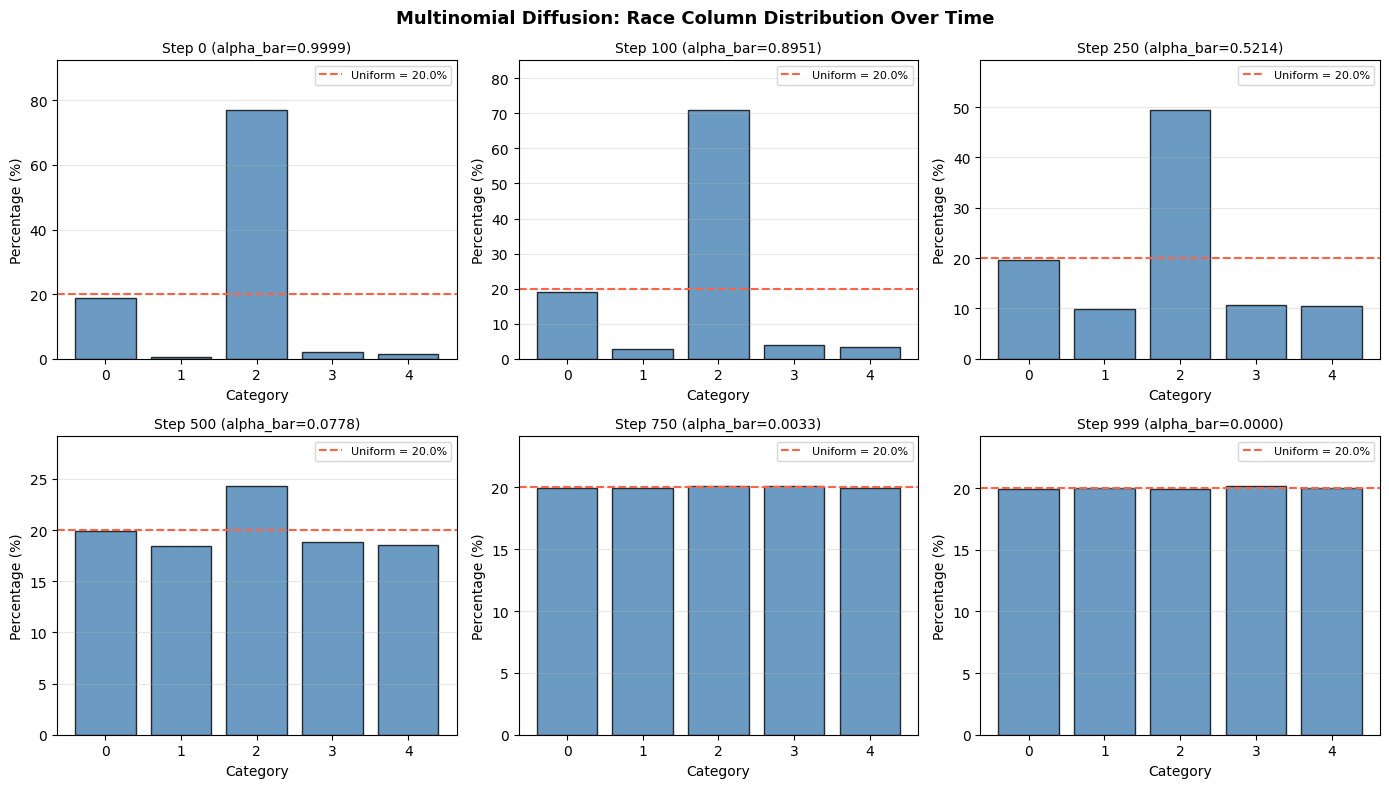

Plot saved to results/figures/multinomial_diffusion_race.png

What to see: the bars start matching the original (uneven) distribution
and gradually flatten toward the red line (uniform/random).


In [82]:
# Visualize multinomial noise on race column 
 
# This plot shows how the category distribution flattens out as noise
# increases. 
 
steps_to_plot = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
 
for idx, step in enumerate(steps_to_plot):
    t_all = torch.full((len(race_values),), step)
    torch.manual_seed(42)  # same noise for reproducibility
    noisy_race = q_sample_multinomial(race_values, t_all, alpha_bars, K_race)
 
    counts = torch.bincount(noisy_race.long(), minlength=K_race).numpy()
    pcts = counts / counts.sum() * 100
 
    bars = axes[idx].bar(range(K_race), pcts, color='steelblue', edgecolor='black', alpha=0.8)
    axes[idx].axhline(y=100/K_race, color='tomato', linestyle='--', linewidth=1.5,
                      label=f'Uniform = {100/K_race:.1f}%')
    axes[idx].set_title(f"Step {step} (alpha_bar={float(alpha_bars[step]):.4f})", fontsize=10)
    axes[idx].set_xlabel("Category")
    axes[idx].set_ylabel("Percentage (%)")
    axes[idx].set_ylim(0, max(pcts) * 1.2)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3, axis='y')
 
plt.suptitle("Multinomial Diffusion: Race Column Distribution Over Time",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/"multinomial_diffusion_race.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Plot saved to results/figures/multinomial_diffusion_race.png")
print("\nWhat to see: the bars start matching the original (uneven) distribution")
print("and gradually flatten toward the red line (uniform/random).")
 

In [84]:
# Test on ALL categorical columns 
 
# I need to verify this works for every categorical column, not just race.
# Each column has a different number of categories (K), so I loop through all 33.
 
print("=== TESTING ALL 33 CATEGORICAL COLUMNS ===\n")
print(f"{'Column':<35s} {'K':>3s}  {'Step 0 top%':>11s}  {'Step 999 top%':>13s}  {'Uniform%':>9s}  {'Status'}")
print("-" * 95)
 
all_passed = True
for col in CAT_COLS:
    K = NUM_CLASSES_PER_CAT[col]
    col_values = torch.tensor(X_train[col].fillna(0).values, dtype=torch.float32)
 
    # test step 0 -- should keep original distribution
    t0 = torch.full((len(col_values),), 0)
    torch.manual_seed(42)
    noisy_0 = q_sample_multinomial(col_values, t0, alpha_bars, K)
    counts_0 = torch.bincount(noisy_0.long(), minlength=K)
    top_pct_0 = float(counts_0.max()) / float(counts_0.sum()) * 100
 
    # test step 999 -- should be nearly uniform
    t999 = torch.full((len(col_values),), 999)
    torch.manual_seed(42)
    noisy_999 = q_sample_multinomial(col_values, t999, alpha_bars, K)
    counts_999 = torch.bincount(noisy_999.long(), minlength=K)
    top_pct_999 = float(counts_999.max()) / float(counts_999.sum()) * 100
 
    uniform_pct = 100.0 / K
 
    # at step 999, the most common category should be close to uniform
    close_to_uniform = abs(top_pct_999 - uniform_pct) < 5.0  # within 5% is fine
    status = "PASS" if close_to_uniform else "CHECK"
    if not close_to_uniform:
        all_passed = False
 
    print(f"{col:<35s} {K:>3d}  {top_pct_0:>10.1f}%  {top_pct_999:>12.1f}%  {uniform_pct:>8.1f}%  {status}")
 
print("-" * 95)
if all_passed:
    print("\nALL 33 CATEGORICAL COLUMNS PASSED!")
else:
    print("\nSome columns marked CHECK -- small K values may have slight variance")

=== TESTING ALL 33 CATEGORICAL COLUMNS ===

Column                                K  Step 0 top%  Step 999 top%   Uniform%  Status
-----------------------------------------------------------------------------------------------
race                                  5        77.0%          20.2%      20.0%  PASS
gender                                2        53.8%          50.2%      50.0%  PASS
admission_type_id                     9        52.7%          11.4%      11.1%  PASS
discharge_disposition_id             29        60.6%           3.7%       3.4%  PASS
admission_source_id                  26        56.2%           4.0%       3.8%  PASS
diag_1                                9        29.9%          11.4%      11.1%  PASS
diag_2                                9        31.3%          11.4%      11.1%  PASS
diag_3                                9        30.2%          11.4%      11.1%  PASS
max_glu_serum                         4        94.8%          25.1%      25.0%  PASS
A1Cresul

In [85]:
# Verify one important property
 
# At step 0, the noisy category should ALMOST ALWAYS be the same
# as the original category (because alpha_bar_0 ~ 1.0).
# Let's check what percentage of values stayed the same at step 0.
 
print("=== PRESERVATION CHECK AT STEP 0 ===\n")
 
col_values = torch.tensor(X_train['race'].fillna(0).values, dtype=torch.float32)
t0 = torch.full((len(col_values),), 0)
torch.manual_seed(42)
noisy_0 = q_sample_multinomial(col_values, t0, alpha_bars, NUM_CLASSES_PER_CAT['race'])
 
same = (noisy_0.long() == col_values.long()).float().mean() * 100
print(f"Race column at step 0: {same:.2f}% of values stayed the same")
print(f"  (Expected: very close to 100% since alpha_bar[0] = {float(alpha_bars[0]):.6f})")
 
# also check step 999
t999 = torch.full((len(col_values),), 999)
torch.manual_seed(42)
noisy_999 = q_sample_multinomial(col_values, t999, alpha_bars, NUM_CLASSES_PER_CAT['race'])
 
same_999 = (noisy_999.long() == col_values.long()).float().mean() * 100
expected_same = float(alpha_bars[999]) * 100 + (1 - float(alpha_bars[999])) * (100 / NUM_CLASSES_PER_CAT['race'])
print(f"\nRace column at step 999: {same_999:.2f}% of values stayed the same")
print(f"  (Expected: ~{expected_same:.1f}% -- mostly random, so close to 1/K = {100/NUM_CLASSES_PER_CAT['race']:.1f}%)")
 
print("\n=== MULTINOMIAL DIFFUSION COMPLETE AND VERIFIED ===")


=== PRESERVATION CHECK AT STEP 0 ===

Race column at step 0: 99.99% of values stayed the same
  (Expected: very close to 100% since alpha_bar[0] = 0.999900)

Race column at step 999: 20.18% of values stayed the same
  (Expected: ~20.0% -- mostly random, so close to 1/K = 20.0%)

=== MULTINOMIAL DIFFUSION COMPLETE AND VERIFIED ===


In [86]:
# The combined function will receive a full patient row as a single tensor.
# I need to know which column POSITIONS are numeric and which are categorical,
# so I can split them, noise them differently, and stitch them back.
 
numeric_indices = [ALL_COLS.index(col) for col in NUMERIC_COLS]
cat_indices = [ALL_COLS.index(col) for col in CAT_COLS]
 
print(f"Total columns: {len(ALL_COLS)}")
print(f"Numeric column positions: {numeric_indices}")
print(f"Categorical column positions (first 10): {cat_indices[:10]}...")
print(f"\nNumeric count: {len(numeric_indices)}, Categorical count: {len(cat_indices)}")
print(f"Sum: {len(numeric_indices) + len(cat_indices)} (should equal {len(ALL_COLS)})")
 
# also build a list of K values in the same order as cat_indices
cat_num_classes = [NUM_CLASSES_PER_CAT[col] for col in CAT_COLS]
print(f"\nCategories per categorical column (first 10): {cat_num_classes[:10]}...")


Total columns: 42
Numeric column positions: [6, 7, 8, 9, 10, 11, 12, 16, 2]
Categorical column positions (first 10): [0, 1, 3, 4, 5, 13, 14, 15, 17, 18]...

Numeric count: 9, Categorical count: 33
Sum: 42 (should equal 42)

Categories per categorical column (first 10): [5, 2, 9, 29, 26, 9, 9, 9, 4, 4]...


In [87]:
# The combined forward diffusion function 
 
# This is the MAIN function your teammates will use.
# It takes a full patient row (all 42 features) and a timestep,
# applies Gaussian noise to numeric columns and multinomial noise
# to categorical columns, and returns the full noisy row.
 
def forward_diffusion(x_0, t, alpha_bars, numeric_indices, cat_indices, cat_num_classes):
    """
    Apply the full forward diffusion process to a batch of patient rows.
 
    This is the main function that Rohith's training loop will call.
 
    Args:
        x_0: original patient data, shape (batch_size, num_features)
             all 42 columns as a single tensor
        t: timesteps, shape (batch_size,)
        alpha_bars: precomputed alpha_bar values, shape (T,)
        numeric_indices: list of column positions for numeric features
        cat_indices: list of column positions for categorical features
        cat_num_classes: list of K values for each categorical column
 
    Returns:
        x_t: the noisy patient data, shape (batch_size, num_features)
        noise: the Gaussian noise used for numeric columns,
               shape (batch_size, num_numeric_features)
               (this is what the neural network will try to predict)
    """
    batch_size = x_0.shape[0]
    num_features = x_0.shape[1]
 
    # start with a copy so I don't modify the original
    x_t = x_0.clone()
 
    # --- handle numeric columns (Gaussian noise) ---
    x_0_numeric = x_0[:, numeric_indices]  # pull out just numeric columns
    x_t_numeric, noise = q_sample_gaussian(x_0_numeric, t, alpha_bars)
    x_t[:, numeric_indices] = x_t_numeric  # put noisy values back
 
    # --- handle categorical columns (multinomial noise) ---
    for i, col_idx in enumerate(cat_indices):
        K = cat_num_classes[i]
        x_0_cat = x_0[:, col_idx]  # one column at a time
        x_t_cat = q_sample_multinomial(x_0_cat, t, alpha_bars, K)
        x_t[:, col_idx] = x_t_cat.float()
 
    return x_t, noise
 
 
print("forward_diffusion function defined!")
print("This is the main function -- takes a full patient row, returns the noisy version.")
print(f"  - Applies Gaussian noise to {len(numeric_indices)} numeric columns")
print(f"  - Applies multinomial diffusion to {len(cat_indices)} categorical columns")
 

forward_diffusion function defined!
This is the main function -- takes a full patient row, returns the noisy version.
  - Applies Gaussian noise to 9 numeric columns
  - Applies multinomial diffusion to 33 categorical columns


In [89]:
# Test on a single full patient row 
 
# grab one patient, all 42 columns
patient_full = torch.tensor(X_train.fillna(0).iloc[0].values, dtype=torch.float32).unsqueeze(0)
 
print(f"Patient shape: {patient_full.shape}  (1 patient, {patient_full.shape[1]} features)")
print(f"\nOriginal patient (first 10 columns):")
for i, col in enumerate(ALL_COLS[:10]):
    print(f"  {col:35s} = {float(patient_full[0, i]):.4f}")
 
print("\n" + "=" * 60)
for step in [0, 250, 500, 999]:
    t_tensor = torch.tensor([step])
    torch.manual_seed(42)
    noisy, noise = forward_diffusion(patient_full, t_tensor, alpha_bars,
                                      numeric_indices, cat_indices, cat_num_classes)
 
    print(f"\nStep {step} (alpha_bar = {float(alpha_bars[step]):.6f}):")
    for i, col in enumerate(ALL_COLS[:10]):
        orig = float(patient_full[0, i])
        noised = float(noisy[0, i])
        changed = " *CHANGED*" if abs(orig - noised) > 0.001 else ""
        print(f"  {col:35s}  orig={orig:+.4f}  noisy={noised:+.4f}{changed}")
 
print("\nWhat to see: at step 0, almost nothing changes.")
print("At step 999, numeric columns become random decimals,")
print("and categorical columns become random integers.")

Patient shape: torch.Size([1, 42])  (1 patient, 42 features)

Original patient (first 10 columns):
  race                                = 2.0000
  gender                              = 1.0000
  age                                 = -0.6735
  admission_type_id                   = 1.0000
  discharge_disposition_id            = 1.0000
  admission_source_id                 = 7.0000
  time_in_hospital                    = -0.1284
  num_lab_procedures                  = 1.1235
  num_procedures                      = -0.7838
  num_medications                     = -0.9855


Step 0 (alpha_bar = 0.999900):
  race                                 orig=+2.0000  noisy=+2.0000
  gender                               orig=+1.0000  noisy=+1.0000
  age                                  orig=-0.6735  noisy=-0.6689 *CHANGED*
  admission_type_id                    orig=+1.0000  noisy=+1.0000
  discharge_disposition_id             orig=+1.0000  noisy=+1.0000
  admission_source_id                  orig=+7.00

In [91]:
# Test on a full batch (what training actually looks like) 
 
batch_size = 64
batch_data = torch.tensor(X_train.fillna(0).iloc[:batch_size].values, dtype=torch.float32)
random_t = torch.randint(0, T, (batch_size,))
 
torch.manual_seed(42)
noisy_batch, noise_batch = forward_diffusion(
    batch_data, random_t, alpha_bars,
    numeric_indices, cat_indices, cat_num_classes
)
 
print(f"Input shape:        {batch_data.shape}  (64 patients, 42 features)")
print(f"Timesteps shape:    {random_t.shape}  (one timestep per patient)")
print(f"Noisy output shape: {noisy_batch.shape}  (same as input, good!)")
print(f"Noise output shape: {noise_batch.shape}  (64 patients, {len(numeric_indices)} numeric features)")
 
print(f"\nTimestep range: min={int(random_t.min())}, max={int(random_t.max())}")
 
# check that categorical columns are still valid integers
print("\n--- Categorical columns validity check ---")
all_valid = True
for i, col_idx in enumerate(cat_indices):
    col_name = CAT_COLS[i]
    K = cat_num_classes[i]
    vals = noisy_batch[:, col_idx]
    min_val = int(vals.min())
    max_val = int(vals.max())
    is_integer = torch.all(vals == vals.long().float())
    valid = min_val >= 0 and max_val < K and is_integer
    if not valid:
        all_valid = False
        print(f"  FAIL: {col_name} has values outside [0, {K-1}]")
 
if all_valid:
    print(f"  ALL {len(cat_indices)} categorical columns have valid integer values!")
 
# check that numeric columns with high timesteps are more noisy
print("\n--- Noise level check ---")
for i in range(min(5, batch_size)):
    t_val = int(random_t[i])
    numeric_diff = float(torch.mean((noisy_batch[i, numeric_indices] - batch_data[i, numeric_indices]) ** 2))
    print(f"  Patient {i}, step {t_val:4d}: numeric MSE from original = {numeric_diff:.4f}")
 
print("\nHigher steps should have larger MSE values.")
 

Input shape:        torch.Size([64, 42])  (64 patients, 42 features)
Timesteps shape:    torch.Size([64])  (one timestep per patient)
Noisy output shape: torch.Size([64, 42])  (same as input, good!)
Noise output shape: torch.Size([64, 9])  (64 patients, 9 numeric features)

Timestep range: min=4, max=972

--- Categorical columns validity check ---
  ALL 33 categorical columns have valid integer values!

--- Noise level check ---
  Patient 0, step  252: numeric MSE from original = 0.6888
  Patient 1, step  264: numeric MSE from original = 1.2228
  Patient 2, step  637: numeric MSE from original = 1.4726
  Patient 3, step  972: numeric MSE from original = 1.0724
  Patient 4, step  360: numeric MSE from original = 1.0824

Higher steps should have larger MSE values.


In [92]:
# Package everything 
 
# Save all the precomputed values that Rohith and Jiten will need.
# They just load this file and call forward_diffusion().
 
import pickle
 
diffusion_config = {
    # noise schedule values
    'T': T,
    'betas': betas,
    'alphas': alphas,
    'alpha_bars': alpha_bars,
 
    # column information
    'all_columns': ALL_COLS,
    'numeric_columns': NUMERIC_COLS,
    'categorical_columns': CAT_COLS,
    'numeric_indices': numeric_indices,
    'cat_indices': cat_indices,
    'cat_num_classes': cat_num_classes,
    'num_classes_per_cat': NUM_CLASSES_PER_CAT,
}
 
save_path = "../models/diffusion_config.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(diffusion_config, f)
 
print(f"Saved diffusion config to {save_path}")
print(f"\nWhat's inside:")
for key, val in diffusion_config.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:25s}  tensor, shape {val.shape}")
    elif isinstance(val, list):
        print(f"  {key:25s}  list, length {len(val)}")
    elif isinstance(val, dict):
        print(f"  {key:25s}  dict, {len(val)} entries")
    else:
        print(f"  {key:25s}  {val}")
 
print(f"\nYour teammates can load this with:")
print(f"  import pickle")
print(f"  with open('models/diffusion_config.pkl', 'rb') as f:")
print(f"      config = pickle.load(f)")
print(f"  alpha_bars = config['alpha_bars']")
print(f"  # etc.")

Saved diffusion config to ../models/diffusion_config.pkl

What's inside:
  T                          1000
  betas                      tensor, shape torch.Size([1000])
  alphas                     tensor, shape torch.Size([1000])
  alpha_bars                 tensor, shape torch.Size([1000])
  all_columns                list, length 42
  numeric_columns            list, length 9
  categorical_columns        list, length 33
  numeric_indices            list, length 9
  cat_indices                list, length 33
  cat_num_classes            list, length 33
  num_classes_per_cat        dict, 33 entries

Your teammates can load this with:
  import pickle
  with open('models/diffusion_config.pkl', 'rb') as f:
      config = pickle.load(f)
  alpha_bars = config['alpha_bars']
  # etc.


In [94]:
print("=" * 65)
print(" FORWARD PROCESS - SUMMARY")
print("=" * 65)
print(f"  Timesteps (T):             {T}")
print(f"  Beta range:                {float(betas[0]):.4f} to {float(betas[-1]):.4f} (linear)")
print(f"  Alpha_bar range:           {float(alpha_bars[0]):.6f} to {float(alpha_bars[-1]):.6f}")
print(f"  Numeric columns:           {len(NUMERIC_COLS)} (Gaussian noise)")
print(f"  Categorical columns:       {len(CAT_COLS)} (multinomial diffusion)")
print(f"  Total features:            {len(ALL_COLS)}")
print(f"")
print(f"  Functions defined:")
print(f"    q_sample_gaussian()      -- noises numeric columns")
print(f"    q_sample_multinomial()   -- noises categorical columns")
print(f"    forward_diffusion()      -- noises a full patient row (calls both)")
print(f"")
print(f"  Saved artifacts:")
print(f"    models/diffusion_config.pkl  -- all schedule values + column info")
print(f"")
print(f"  Saved figures:")
print(f"    results/figures/noise_schedule.png")
print(f"    results/figures/noise_buildup_single_patient.png")
print(f"    results/figures/multinomial_diffusion_race.png")
print("=" * 65)
print(f"\n  Ready for neural network and training loop!")

 FORWARD PROCESS - SUMMARY
  Timesteps (T):             1000
  Beta range:                0.0001 to 0.0200 (linear)
  Alpha_bar range:           0.999900 to 0.000040
  Numeric columns:           9 (Gaussian noise)
  Categorical columns:       33 (multinomial diffusion)
  Total features:            42

  Functions defined:
    q_sample_gaussian()      -- noises numeric columns
    q_sample_multinomial()   -- noises categorical columns
    forward_diffusion()      -- noises a full patient row (calls both)

  Saved artifacts:
    models/diffusion_config.pkl  -- all schedule values + column info

  Saved figures:
    results/figures/noise_schedule.png
    results/figures/noise_buildup_single_patient.png
    results/figures/multinomial_diffusion_race.png

  Ready for neural network and training loop!


C:\Users\anums\AppData\Local\Temp\ipykernel_2660\806955132.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


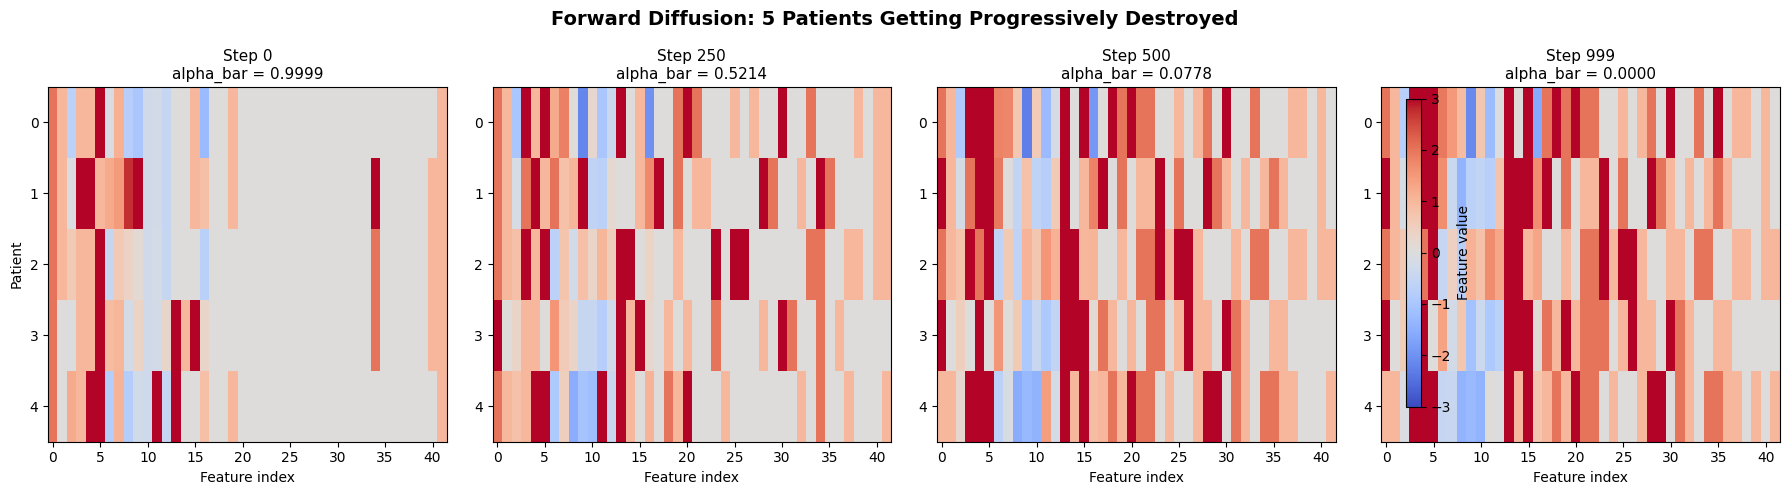

Saved to results/figures/forward_diffusion_heatmap.png

What to see:
  Step 0: clear structure and patterns in the data
  Step 999: pure random noise -- no patterns, just color soup


In [95]:
# Heatmap -- real vs noisy patients at different steps 
 
# Important visualization for report also
# It shows 5 real patients as a heatmap, then the same 5 patients
# at step 250, 500, and 999. You can visually SEE the data getting
# destroyed. Colors go from structured (patterns visible) to random.
 
num_patients = 5
steps_to_show = [0, 250, 500, 999]
 
# grab 5 patients, all columns, fill NaN with 0
sample = torch.tensor(
    X_train.fillna(0).iloc[:num_patients].values, dtype=torch.float32
)
 
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(18, 5))
 
for idx, step in enumerate(steps_to_show):
    t_tensor = torch.full((num_patients,), step)
    torch.manual_seed(42)
    noisy, _ = forward_diffusion(sample, t_tensor, alpha_bars,
                                  numeric_indices, cat_indices, cat_num_classes)
 
    im = axes[idx].imshow(noisy.numpy(), aspect='auto', cmap='coolwarm',
                          vmin=-3, vmax=3)
    axes[idx].set_title(f"Step {step}\nalpha_bar = {float(alpha_bars[step]):.4f}",
                        fontsize=11)
    axes[idx].set_xlabel("Feature index")
    if idx == 0:
        axes[idx].set_ylabel("Patient")
    axes[idx].set_yticks(range(num_patients))
 
fig.colorbar(im, ax=axes, shrink=0.8, label="Feature value")
plt.suptitle("Forward Diffusion: 5 Patients Getting Progressively Destroyed",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR /"forward_diffusion_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved to results/figures/forward_diffusion_heatmap.png")
print("\nWhat to see:")
print("  Step 0: clear structure and patterns in the data")
print("  Step 999: pure random noise -- no patterns, just color soup")
 

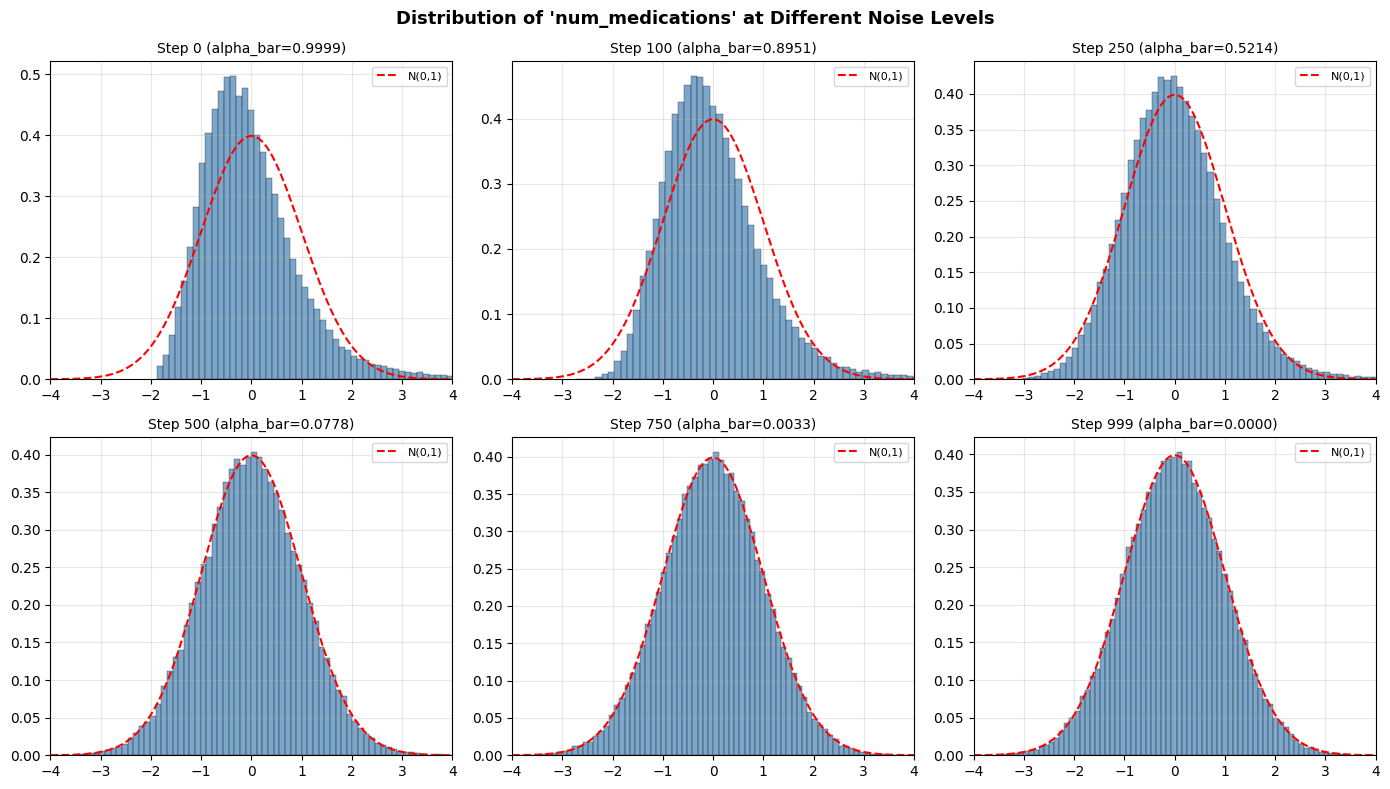

Saved to results/figures/distribution_shift_numeric.png

What to see: the original distribution (step 0) gradually morphs
into a perfect standard normal (red dashed line) by step 999.


In [96]:
# Distribution shift plot -- full training set 
 
# This shows how the DISTRIBUTION of one numeric column changes
# at different noise levels. Great for showing that by step 999,
# all features converge to a standard normal distribution.
 
feature_name = 'num_medications'
feat_idx = NUMERIC_COLS.index(feature_name)
 
full_numeric = torch.tensor(
    X_train[NUMERIC_COLS].values, dtype=torch.float32
)
 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
 
steps_to_show = [0, 100, 250, 500, 750, 999]
for idx, step in enumerate(steps_to_show):
    t_all = torch.full((full_numeric.shape[0],), step)
    noisy_all, _ = q_sample_gaussian(full_numeric, t_all, alpha_bars)
 
    vals = noisy_all[:, feat_idx].numpy()
 
    axes[idx].hist(vals, bins=80, density=True, color='steelblue',
                   edgecolor='black', alpha=0.7, linewidth=0.3)
 
    # overlay standard normal for reference
    x_range = np.linspace(-4, 4, 200)
    normal_pdf = np.exp(-x_range**2 / 2) / np.sqrt(2 * np.pi)
    axes[idx].plot(x_range, normal_pdf, 'r--', linewidth=1.5, label='N(0,1)')
 
    axes[idx].set_title(f"Step {step} (alpha_bar={float(alpha_bars[step]):.4f})", fontsize=10)
    axes[idx].set_xlim(-4, 4)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)
 
plt.suptitle(f"Distribution of '{feature_name}' at Different Noise Levels",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR /"distribution_shift_numeric.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved to results/figures/distribution_shift_numeric.png")
print("\nWhat to see: the original distribution (step 0) gradually morphs")
print("into a perfect standard normal (red dashed line) by step 999.")

In [ ]:
# Final file listing 
 
import os
 
print("=" * 65)
print("  FORWARD PROCESS -- ALL DELIVERABLES")
print("=" * 65)
 
figures_dir = FIGURES_DIR
models_dir = "../models"
 
print("\n  Figures (for report):")
for fname in sorted(os.listdir(figures_dir)):
    fpath = os.path.join(figures_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"    {fname:45s} ({size_kb:.0f} KB)")
 
print(f"\n  Model artifacts:")
for fname in sorted(os.listdir(models_dir)):
    fpath = os.path.join(models_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"    {fname:45s} ({size_kb:.0f} KB)")
 
print(f"\n  Functions defined in this notebook:")
print(f"    q_sample_gaussian(x_0, t, alpha_bars)")
print(f"    q_sample_multinomial(x_0_cat, t, alpha_bars, num_classes)")
print(f"    forward_diffusion(x_0, t, alpha_bars, numeric_idx, cat_idx, cat_K)")
print(f"\n  Config file for teammates: models/diffusion_config.pkl")
print(f"    Contains: betas, alphas, alpha_bars, column lists, indices, K values")
print("=" * 65)
print("\n  FORWARD PROCESS IS DONE!")

print("=" * 65)